<i>Mateusz Konieczny, 02.07.2026 - the date I started this project</i>

# Titanic disaster - dataset

Hey, my name is Mateusz. I am a complete beginner in machine learning and data science, but I would love to learn this beautiful expertise. I will try to keep up with writing down every thought in this notebook so that you could clearly see my reasoning (and also, for myself once I would try to reach back the old days). I will try to explain everything what I am going to use, hence this is the best way to learn, at least that is what they say.

Okay, so let us first introduce the basic libraries and the data!

## 1. Libraries & data

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv('train.csv')
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


To move one we have to better understand the data. We will do some Exploratory Data Analysis (EDA) to get maybe some useful insights.

## 2. Exploratory Data Analysis (EDA)

### 2.0 Data validation

We need to test whether the data are valid. If there is no missing values, etc.

In [2]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


We don't have null values and for me there is not a big need for data cleaning. Let's move on with EDA.

### 2.1 Gender

Obviously, the gender trend in titanic is the most popular, so we will check it first.


In [11]:
women = train_data.loc[train_data.Sex == 'female']['Survived']
rate_women = sum(women) / len(women)
print(f"& of women who survived: {rate_women}")

& of women who survived: 0.7420382165605095


In [12]:
male = train_data.loc[train_data.Sex == 'male']['Survived']
rate_male = sum(male) / len(male)
print(f"& of men who survived: {rate_male}")

& of men who survived: 0.18890814558058924


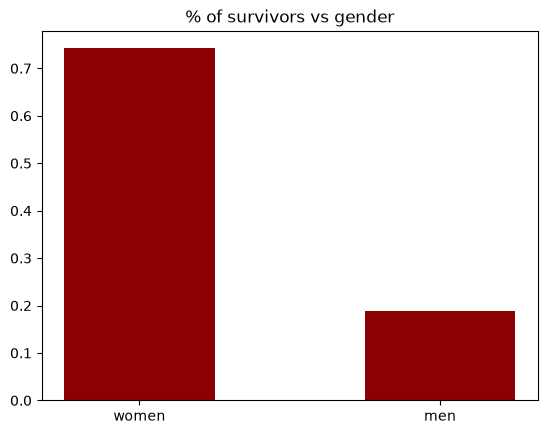

In [13]:
# Here I am just having fun creating it
plt.bar(['women', 'men'], [rate_women, rate_male], width=0.5, color='darkred')
plt.title('% of survivors vs gender')
plt.show()

The conclusion is obvious, being a woman you're more likely to survive :)

### 2.2 Correlation matrix and heatmap

I think that may be a good idea, I got an error doing that, and I was wondering what I did wrong, but I finally found out that in our data we have columns with string type, correlation works only for numbers.

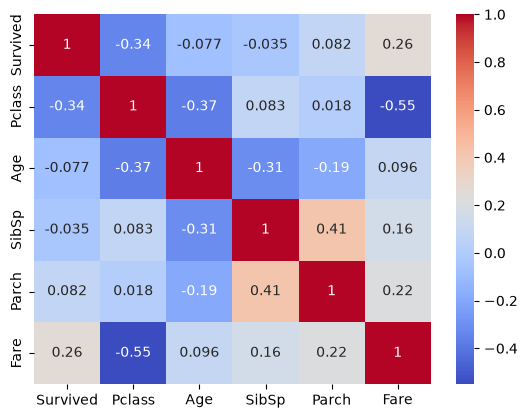

In [17]:
'''
PassengerId  891 non-null    int64
Survived     891 non-null    int64
Pclass       891 non-null    int64
Name         891 non-null    str
Sex          891 non-null    str
Age          714 non-null    float64
SibSp        891 non-null    int64
Parch        891 non-null    int64
Ticket       891 non-null    str
Fare         891 non-null    float64
Cabin        204 non-null    str
Embarked     889 non-null    str
'''

no_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = train_data[no_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

We have little correlation with Pclass and Fare, they are quite similiar I would say. The greater the price of the fare the better class, I guess.